<a href="https://colab.research.google.com/github/ziadm8692-glitch/Data-Analysis-Portfolio/blob/main/Project_6_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler




In [ ]:
df=pd.read_csv('/content/Stores.csv')
df.head()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
0,1,1659,1961,530,66490
1,2,1461,1752,210,39820
2,3,1340,1609,720,54010
3,4,1451,1748,620,53730
4,5,1770,2111,450,46620


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Store ID              896 non-null    int64
 1   Store_Area            896 non-null    int64
 2   Items_Available       896 non-null    int64
 3   Daily_Customer_Count  896 non-null    int64
 4   Store_Sales           896 non-null    int64
dtypes: int64(5)
memory usage: 35.1 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
count,896.000000,896.000000,896.000000,896.000000,896.000000
mean,448.500000,1485.409598,1782.035714,786.350446,59351.305804
std,258.797218,250.237011,299.872053,265.389281,17190.741895
min,1.000000,775.000000,932.000000,10.000000,14920.000000
25%,224.750000,1316.750000,1575.500000,600.000000,46530.000000
50%,448.500000,1477.000000,1773.500000,780.000000,58605.000000
75%,672.250000,1653.500000,1982.750000,970.000000,71872.500000
max,896.000000,2229.000000,2667.000000,1560.000000,116320.000000


In [ ]:
df.isnull().sum()

,0
Store ID,0
Store_Area,0
Items_Available,0
Daily_Customer_Count,0
Store_Sales,0


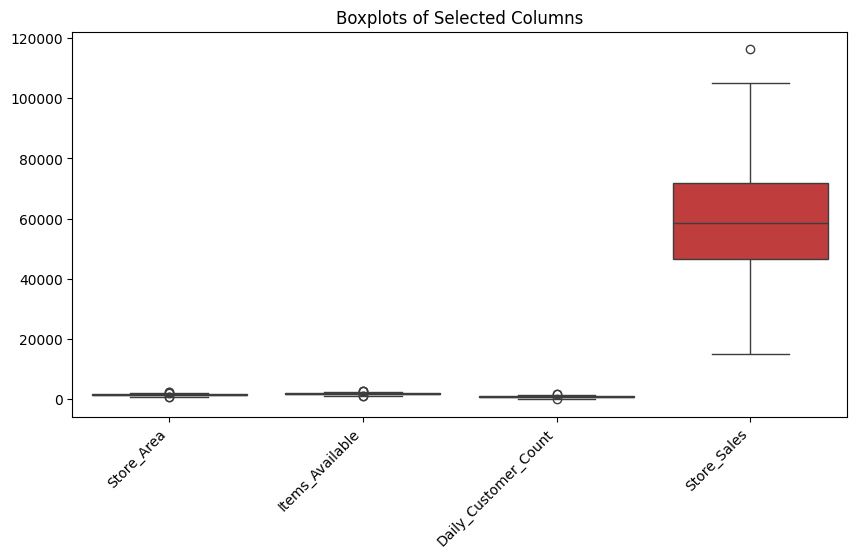

In [ ]:
columns_to_plot = ['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_plot])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplots of Selected Columns')
plt.show()

In [ ]:
Q1=df[['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']].quantile(0.25)
Q3=df[['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']].quantile(0.75)
IQR=Q3-Q1
Lower=Q1-1.5*IQR
Upper=Q3+1.5*IQR
df[['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']]=df[['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']].clip(Lower,Upper, axis=1)

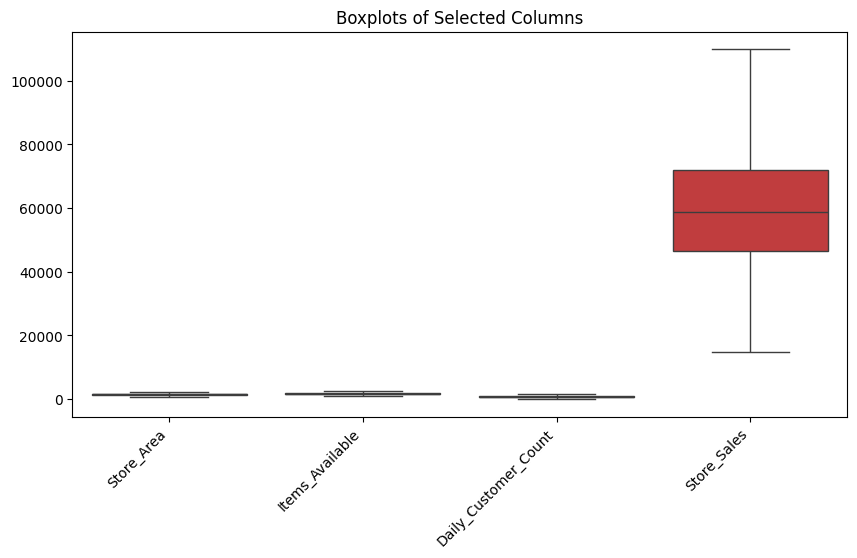

In [ ]:
columns_to_plot = ['Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_plot])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplots of Selected Columns')
plt.show()

In [ ]:
df.dtypes

,0
Store ID,int64
Store_Area,float64
Items_Available,float64
Daily_Customer_Count,int64
Store_Sales,float64


In [ ]:
avg_sales=np.mean(df['Store_Sales'])
print(f"avg_sales {avg_sales}")

avg_sales 59344.125279017855


/tmp/ipykernel_30569/3531162955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Store_Area'].head(10),y=V,data=df,palette='magma')


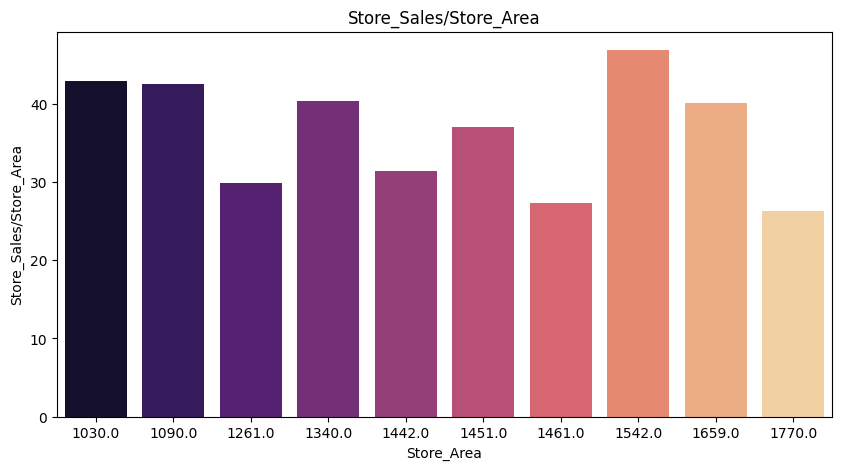

In [ ]:
V=df['Store_Sales']/df['Store_Area']
plt.figure(figsize=(10,5))
sns.barplot(x=df['Store_Area'].head(10),y=V,data=df,palette='magma')
plt.title('Store_Sales/Store_Area')
plt.xlabel('Store_Area')
plt.ylabel('Store_Sales/Store_Area')
plt.show()

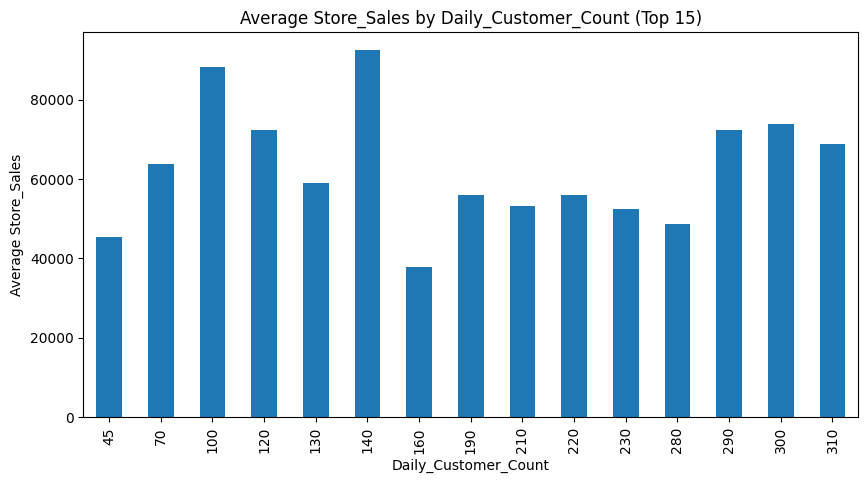

In [ ]:
grouped_sales = df.groupby('Daily_Customer_Count')['Store_Sales'].mean().head(15)
plt.figure(figsize=(10, 5))
grouped_sales.plot(kind='bar')
plt.title('Average Store_Sales by Daily_Customer_Count (Top 15)')
plt.xlabel('Daily_Customer_Count')
plt.ylabel('Average Store_Sales')
plt.show()

<Axes: xlabel='Store_Sales', ylabel='Count'>

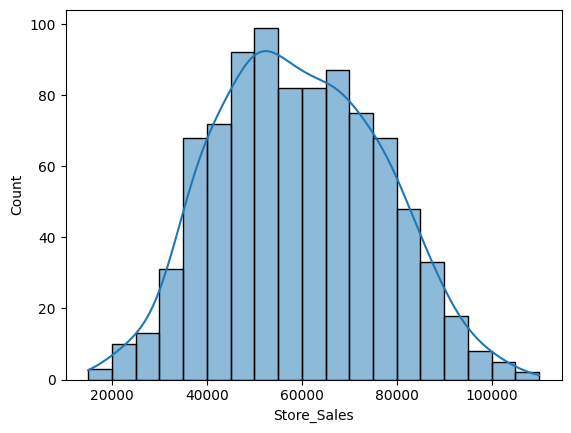

In [ ]:
sns.histplot(df['Store_Sales'], kde=True)

/tmp/ipykernel_30569/1967371523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Store_Area'].head(10), y=D, data=df, palette='magma')


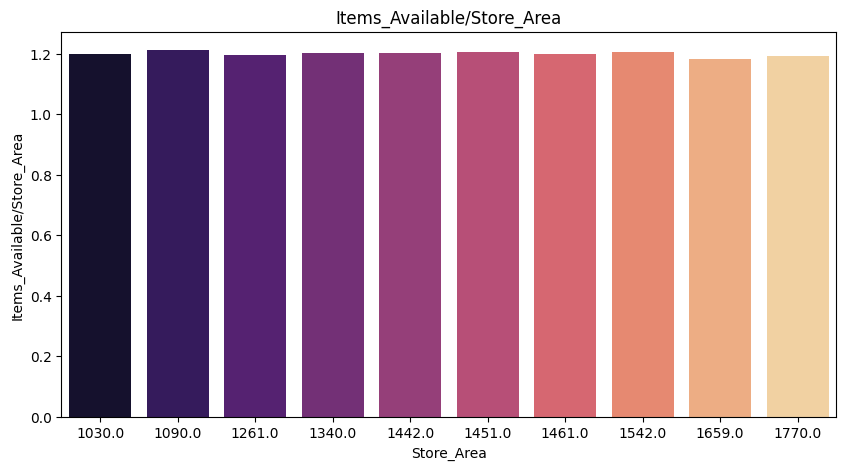

In [ ]:
D = df['Items_Available'] / df['Store_Area']
plt.figure(figsize=(10,5))
sns.barplot(x=df['Store_Area'].head(10), y=D, data=df, palette='magma')
plt.title('Items_Available/Store_Area')
plt.xlabel('Store_Area')
plt.ylabel('Items_Available/Store_Area')
plt.show()

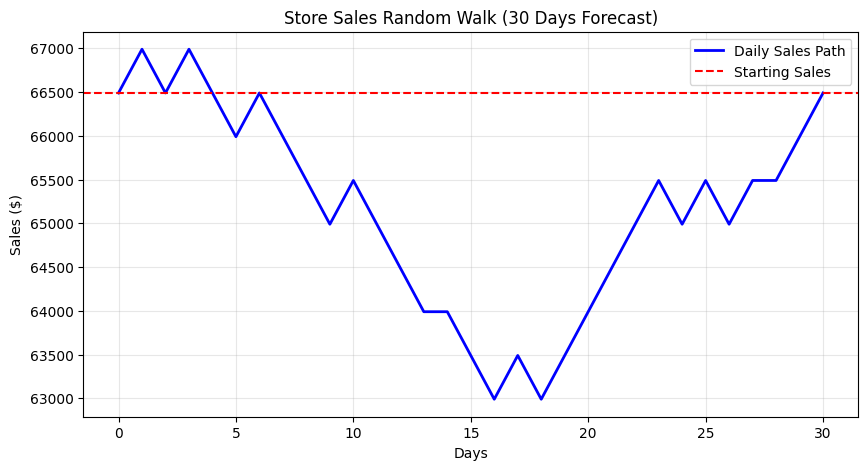

In [ ]:
Sales_New = df['Store_Sales'].iloc[0] # Take the first sales value as the starting point
walk = [Sales_New]
p_gain = 0.52
p_loss = 0.45
p_stay = 1 - (p_gain + p_loss)
step_size = 500
for i in range(30):
  change = np.random.choice([step_size, -step_size, 0], p=[p_gain, p_loss, p_stay])
  new_value = walk[-1] + change
  walk.append(new_value)
plt.figure(figsize=(10, 5))
plt.plot(walk, label='Daily Sales Path', color='blue', linewidth=2)
plt.axhline(y=Sales_New, color='red', linestyle='--', label='Starting Sales')
plt.title('Store Sales Random Walk (30 Days Forecast)')
plt.xlabel('Days')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

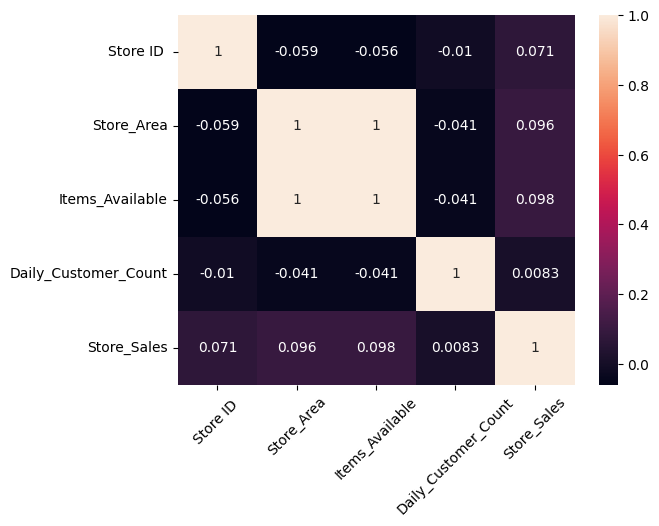

In [ ]:
sns.heatmap(df.corr(),annot=True)
plt.xticks(rotation=45)
plt.show()

In [ ]:
x=df.drop(['Store_Sales'],axis=1)
y=df['Store_Sales']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=200,max_depth=None,random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pre=model.predict(x_test)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pre)
r2 = r2_score(y_test, y_pre)

In [ ]:
mae

13620.983055555555

In [ ]:
avg_sales = y_test.mean()
print(f" {avg_sales}")
print(f" {mae}")
print(f" {(mae / avg_sales) * 100:.2f}%")

 60035.256944444445
 13620.983055555555
 22.69%


In [ ]:
avg_sales = y_test.mean()
print(f"متوسط المبيعات: {avg_sales}")
print(f"مقدار الغلطة (MAE): {mae}")
print(f"نسبة الغلط بالنسبة للمتوسط: {(mae / avg_sales) * 100:.2f}%")

متوسط المبيعات: 60035.256944444445
مقدار الغلطة (MAE): 13620.983055555555
نسبة الغلط بالنسبة للمتوسط: 22.69%


In [ ]:
r2

-0.1095455276140016

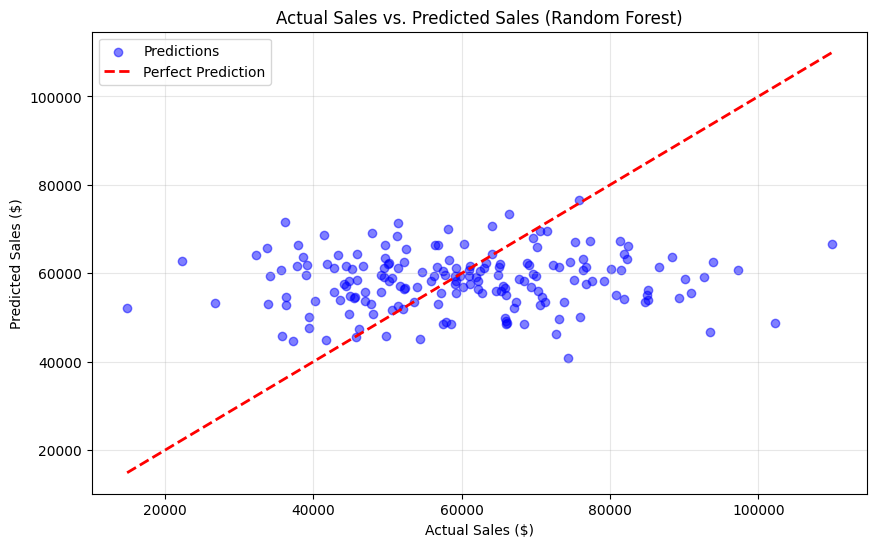

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# رسم النقط (الحقيقية ضد المتوقعة)
plt.scatter(y_test, y_pre, alpha=0.5, color='blue', label='Predictions')
# رسم خط الـ 45 درجة (خط الكمال)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual Sales vs. Predicted Sales (Random Forest)')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_30569/2090966883.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=data, palette='viridis')


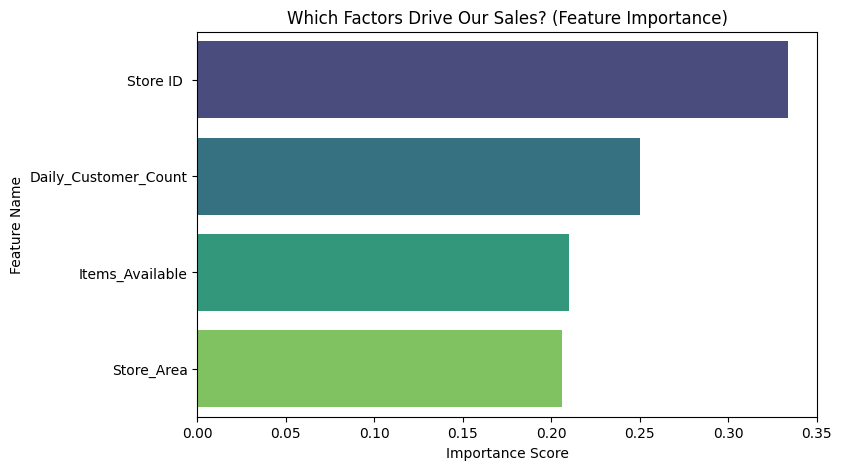

In [ ]:
# حساب الأهمية وترتيبها
importances = model.feature_importances_
features = x.columns
data = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=data, palette='viridis')
plt.title('Which Factors Drive Our Sales? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()